In [2]:
# ШАГ 1. Импортируем библиотеки
import os
import json
import copy
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset, Dataset

import torchvision
from torchvision import datasets, transforms, models
from torchvision.transforms import InterpolationMode
from torchvision.models import ResNet18_Weights
from torchvision.models.segmentation import DeepLabV3_ResNet50_Weights
from torchvision.utils import draw_segmentation_masks

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

# ШАГ 2. Фиксируем seed для воспроизводимости
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ШАГ 3. Определяем устройство
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ШАГ 4. Настраиваем пути проекта
BASE_DIR = Path(".")
ARTIFACTS_DIR = BASE_DIR / "artifacts"
FIGURES_DIR = ARTIFACTS_DIR / "figures"
DATA_DIR = BASE_DIR / "data"

ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)

print("BASE_DIR:", BASE_DIR.resolve())
print("ARTIFACTS_DIR:", ARTIFACTS_DIR.resolve())
print("FIGURES_DIR:", FIGURES_DIR.resolve())
print("DATA_DIR:", DATA_DIR.resolve())

Device: cuda
BASE_DIR: C:\Users\Dilvi\Desktop\Mirea-aie-dpo\homeworks\HW10-11
ARTIFACTS_DIR: C:\Users\Dilvi\Desktop\Mirea-aie-dpo\homeworks\HW10-11\artifacts
FIGURES_DIR: C:\Users\Dilvi\Desktop\Mirea-aie-dpo\homeworks\HW10-11\artifacts\figures
DATA_DIR: C:\Users\Dilvi\Desktop\Mirea-aie-dpo\homeworks\HW10-11\data


In [3]:
# ШАГ 5. Вспомогательный Dataset-обёртка:
class TransformSubset(Dataset):
    def __init__(self, dataset, indices, transform=None, target_transform=None):
        self.dataset = dataset
        self.indices = indices
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        x, y = self.dataset[self.indices[idx]]
        if self.transform is not None:
            x = self.transform(x)
        if self.target_transform is not None:
            y = self.target_transform(y)
        return x, y


# ШАГ 6. Функция для красивого показа изображений
def show_images(images, labels=None, class_names=None, ncols=4, title=None):
    n = len(images)
    nrows = math.ceil(n / ncols)
    plt.figure(figsize=(4 * ncols, 4 * nrows))

    for i, img in enumerate(images):
        plt.subplot(nrows, ncols, i + 1)

        if torch.is_tensor(img):
            img = img.detach().cpu()
            if img.ndim == 3 and img.shape[0] in [1, 3]:
                img = img.permute(1, 2, 0).numpy()

        if isinstance(img, np.ndarray):
            img_min, img_max = img.min(), img.max()
            if img_max > img_min:
                img = (img - img_min) / (img_max - img_min)

        plt.imshow(img)
        plt.axis("off")

        if labels is not None:
            if class_names is not None:
                plt.title(str(class_names[labels[i]]))
            else:
                plt.title(str(labels[i]))

    if title:
        plt.suptitle(title)
    plt.tight_layout()
    plt.show()


# ШАГ 7. Функция сохранения результатов в runs.csv
def append_run(row_dict, csv_path=ARTIFACTS_DIR / "runs.csv"):
    columns = [
        "experiment_id",
        "task",
        "dataset",
        "seed",
        "model_summary",
        "optimizer",
        "lr",
        "epochs_trained",
        "best_val_accuracy",
        "test_accuracy",
        "precision",
        "recall",
        "mean_iou",
        "notes",
    ]

    row = {col: row_dict.get(col, "") for col in columns}
    df_new = pd.DataFrame([row])

    if csv_path.exists() and csv_path.stat().st_size > 0:
        df_old = pd.read_csv(csv_path)
        df_old = df_old[df_old["experiment_id"] != row["experiment_id"]]
        df = pd.concat([df_old, df_new], ignore_index=True)
    else:
        df = df_new

    df.to_csv(csv_path, index=False)


# ШАГ 8. Функция вычисления accuracy
def accuracy_from_logits(logits, targets):
    preds = logits.argmax(dim=1)
    correct = (preds == targets).sum().item()
    total = targets.size(0)
    return correct / total

In [4]:
# ШАГ 9. Определяем transforms для STL10

# Нормализация для STL10
stl10_mean = (0.4467, 0.4398, 0.4066)
stl10_std = (0.2603, 0.2566, 0.2713)

# Базовый transform для простой CNN
cnn_base_transform = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.ToTensor(),
    transforms.Normalize(mean=stl10_mean, std=stl10_std),
])

# Transform с аугментациями для простой CNN
cnn_aug_transform = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop((96, 96), padding=8),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=stl10_mean, std=stl10_std),
])

# Preprocessing для ResNet18 с pretrained weights
resnet_weights = ResNet18_Weights.DEFAULT
resnet_preprocess = resnet_weights.transforms()

print("Transforms prepared.")

Transforms prepared.


In [6]:
# ШАГ 10. Загружаем STL10
raw_train_stl10 = datasets.STL10(
    root=DATA_DIR,
    split="train",
    download=True,
    transform=None,
)

raw_test_stl10 = datasets.STL10(
    root=DATA_DIR,
    split="test",
    download=True,
    transform=None,
)

class_names_a = raw_train_stl10.classes
num_classes_a = len(class_names_a)

print("Число классов:", num_classes_a)
print("Классы:", class_names_a)

# ШАГ 11. Делаем reproducible split train/val = 80/20
train_size = int(0.8 * len(raw_train_stl10))
val_size = len(raw_train_stl10) - train_size

generator = torch.Generator().manual_seed(SEED)
train_subset_tmp, val_subset_tmp = random_split(
    range(len(raw_train_stl10)),
    [train_size, val_size],
    generator=generator,
)

train_indices = list(train_subset_tmp)
val_indices = list(val_subset_tmp)
test_indices = list(range(len(raw_test_stl10)))

print("Train size:", len(train_indices))
print("Val size:", len(val_indices))
print("Test size:", len(test_indices))

# ШАГ 12. Готовим разные версии датасета под разные эксперименты
# C1 - simple-cnn-base
# C2 - simple-cnn-aug
# C3/C4 - resnet18
train_ds_c1 = TransformSubset(raw_train_stl10, train_indices, transform=cnn_base_transform)
val_ds_c1 = TransformSubset(raw_train_stl10, val_indices, transform=cnn_base_transform)
test_ds_c1 = TransformSubset(raw_test_stl10, test_indices, transform=cnn_base_transform)

train_ds_c2 = TransformSubset(raw_train_stl10, train_indices, transform=cnn_aug_transform)
val_ds_c2 = TransformSubset(raw_train_stl10, val_indices, transform=cnn_base_transform)
test_ds_c2 = TransformSubset(raw_test_stl10, test_indices, transform=cnn_base_transform)

train_ds_resnet = TransformSubset(raw_train_stl10, train_indices, transform=resnet_preprocess)
val_ds_resnet = TransformSubset(raw_train_stl10, val_indices, transform=resnet_preprocess)
test_ds_resnet = TransformSubset(raw_test_stl10, test_indices, transform=resnet_preprocess)

# ШАГ 13. Создаём DataLoader
BATCH_SIZE = 64

loaders_a = {
    "C1": {
        "train": DataLoader(train_ds_c1, batch_size=BATCH_SIZE, shuffle=True, num_workers=0),
        "val": DataLoader(val_ds_c1, batch_size=BATCH_SIZE, shuffle=False, num_workers=0),
        "test": DataLoader(test_ds_c1, batch_size=BATCH_SIZE, shuffle=False, num_workers=0),
    },
    "C2": {
        "train": DataLoader(train_ds_c2, batch_size=BATCH_SIZE, shuffle=True, num_workers=0),
        "val": DataLoader(val_ds_c2, batch_size=BATCH_SIZE, shuffle=False, num_workers=0),
        "test": DataLoader(test_ds_c2, batch_size=BATCH_SIZE, shuffle=False, num_workers=0),
    },
    "C3": {
        "train": DataLoader(train_ds_resnet, batch_size=BATCH_SIZE, shuffle=True, num_workers=0),
        "val": DataLoader(val_ds_resnet, batch_size=BATCH_SIZE, shuffle=False, num_workers=0),
        "test": DataLoader(test_ds_resnet, batch_size=BATCH_SIZE, shuffle=False, num_workers=0),
    },
    "C4": {
        "train": DataLoader(train_ds_resnet, batch_size=BATCH_SIZE, shuffle=True, num_workers=0),
        "val": DataLoader(val_ds_resnet, batch_size=BATCH_SIZE, shuffle=False, num_workers=0),
        "test": DataLoader(test_ds_resnet, batch_size=BATCH_SIZE, shuffle=False, num_workers=0),
    },
}

# ШАГ 14. Sanity-check по части A
x_batch, y_batch = next(iter(loaders_a["C1"]["train"]))
print("x_batch.shape:", x_batch.shape)
print("y_batch.shape:", y_batch.shape)
print("Пример labels:", y_batch[:10].tolist())

100.0%


Число классов: 10
Классы: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']
Train size: 4000
Val size: 1000
Test size: 8000
x_batch.shape: torch.Size([64, 3, 96, 96])
y_batch.shape: torch.Size([64])
Пример labels: [0, 9, 8, 4, 5, 6, 1, 8, 9, 0]


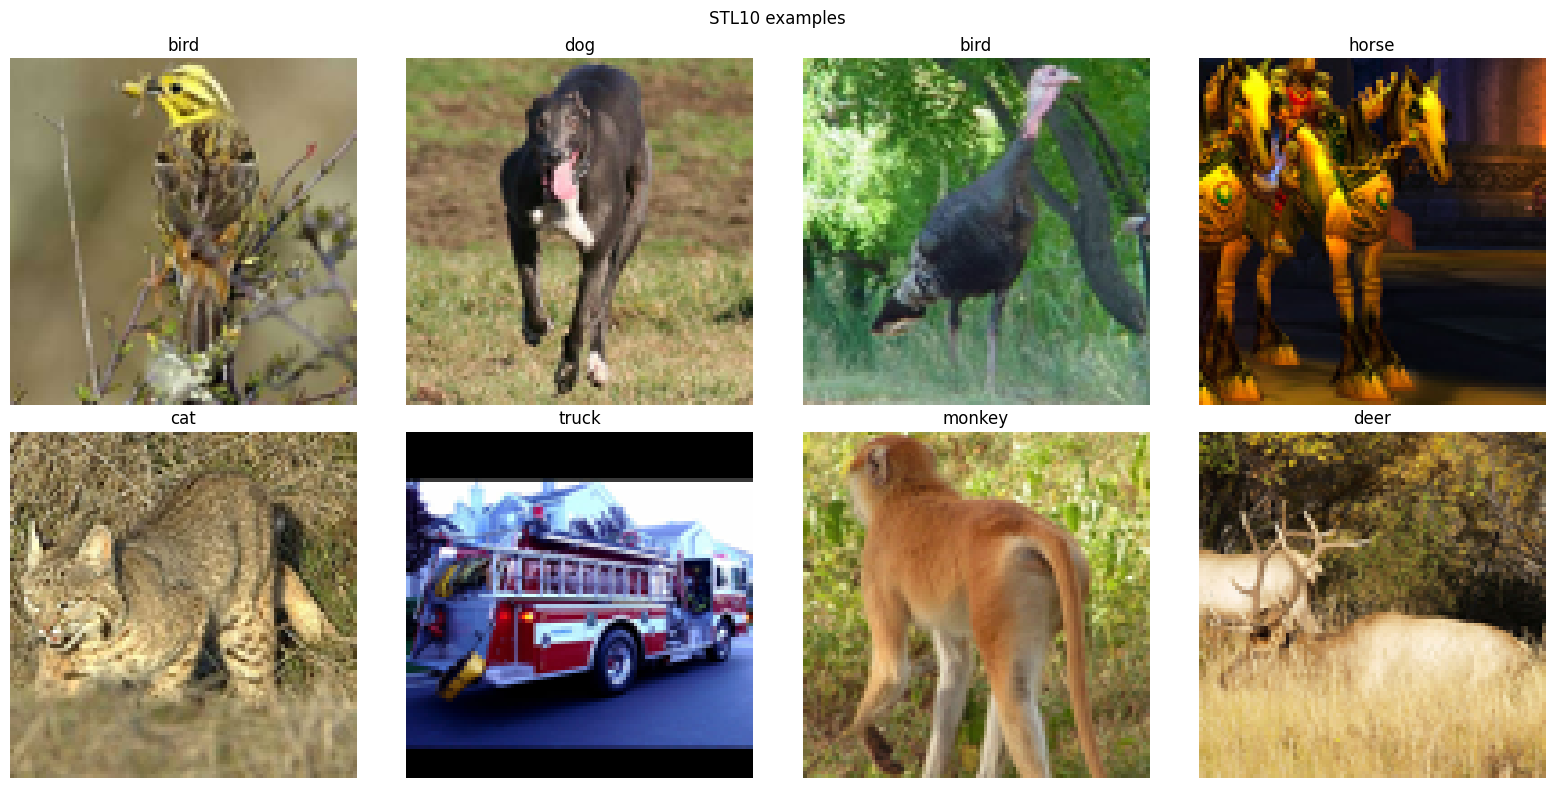

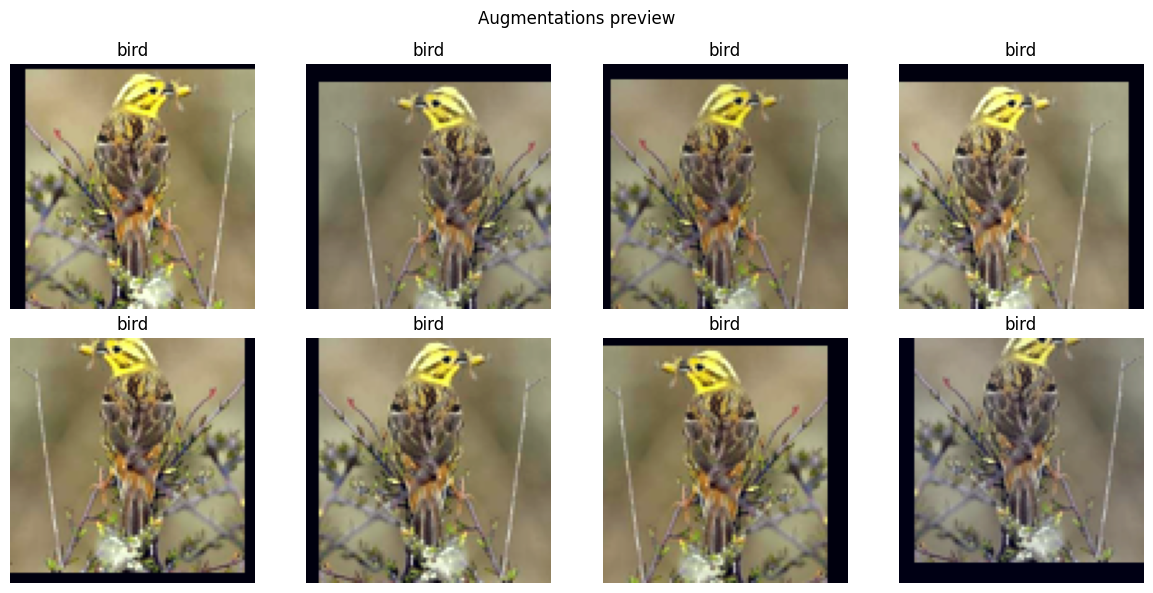

In [7]:
# ШАГ 15. Показываем несколько примеров STL10 без transform
raw_images = []
raw_labels = []

for i in range(8):
    img, label = raw_train_stl10[i]
    raw_images.append(np.array(img))
    raw_labels.append(label)

show_images(raw_images, raw_labels, class_names=class_names_a, ncols=4, title="STL10 examples")


# ШАГ 16. Показываем аугментации на одном изображении
sample_img, sample_label = raw_train_stl10[0]

aug_preview = [cnn_aug_transform(sample_img) for _ in range(8)]

plt.figure(figsize=(12, 6))
for i, img_t in enumerate(aug_preview):
    plt.subplot(2, 4, i + 1)
    img_np = img_t.permute(1, 2, 0).cpu().numpy()
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-8)
    plt.imshow(img_np)
    plt.axis("off")
    plt.title(class_names_a[sample_label])

plt.suptitle("Augmentations preview")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "augmentations_preview.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
# ШАГ 17. Создаём простую CNN для C1 и C2
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2), 

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


model_tmp = SimpleCNN(num_classes_a).to(device)
dummy = torch.randn(4, 3, 96, 96).to(device)
out = model_tmp(dummy)
print("SimpleCNN output shape:", out.shape)

SimpleCNN output shape: torch.Size([4, 10])


In [9]:
# ШАГ 18. Реализуем train_one_epoch(...)
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x.size(0)
        preds = logits.argmax(dim=1)
        running_correct += (preds == y).sum().item()
        running_total += y.size(0)

    epoch_loss = running_loss / running_total
    epoch_acc = running_correct / running_total
    return epoch_loss, epoch_acc


# ШАГ 19. Реализуем evaluate(...)
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        loss = criterion(logits, y)

        running_loss += loss.item() * x.size(0)
        preds = logits.argmax(dim=1)
        running_correct += (preds == y).sum().item()
        running_total += y.size(0)

    epoch_loss = running_loss / running_total
    epoch_acc = running_correct / running_total
    return epoch_loss, epoch_acc

In [10]:
# ШАГ 20. Функция полного запуска эксперимента классификации
def run_classification_experiment(
    experiment_id,
    model,
    train_loader,
    val_loader,
    test_loader,
    optimizer,
    lr,
    epochs,
    model_summary,
):
    criterion = nn.CrossEntropyLoss()

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
    }

    best_val_acc = -1.0
    best_state = None
    best_epoch = -1

    model = model.to(device)

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"[{experiment_id}] Epoch {epoch+1}/{epochs} | "
            f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
        )

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch + 1

    model.load_state_dict(best_state)

    test_loss, test_acc = evaluate(model, test_loader, criterion, device)

    result = {
        "experiment_id": experiment_id,
        "history": history,
        "best_val_accuracy": best_val_acc,
        "test_accuracy": test_acc,
        "best_epoch": best_epoch,
        "best_state_dict": best_state,
        "model_summary": model_summary,
        "optimizer_name": optimizer.__class__.__name__,
        "lr": lr,
        "epochs_trained": epochs,
        "model": model,
    }
    return result

In [11]:
# ШАГ 21. Эксперимент C1: simple-cnn-base
torch.manual_seed(SEED)

model_c1 = SimpleCNN(num_classes=num_classes_a)
optimizer_c1 = optim.Adam(model_c1.parameters(), lr=1e-3)

result_c1 = run_classification_experiment(
    experiment_id="C1",
    model=model_c1,
    train_loader=loaders_a["C1"]["train"],
    val_loader=loaders_a["C1"]["val"],
    test_loader=loaders_a["C1"]["test"],
    optimizer=optimizer_c1,
    lr=1e-3,
    epochs=8,
    model_summary="SimpleCNN without augmentations",
)

append_run({
    "experiment_id": "C1",
    "task": "classification",
    "dataset": "STL10",
    "seed": SEED,
    "model_summary": result_c1["model_summary"],
    "optimizer": result_c1["optimizer_name"],
    "lr": result_c1["lr"],
    "epochs_trained": result_c1["epochs_trained"],
    "best_val_accuracy": result_c1["best_val_accuracy"],
    "test_accuracy": "",
    "precision": "",
    "recall": "",
    "mean_iou": "",
    "notes": "simple-cnn-base",
})

[C1] Epoch 1/8 | train_loss=1.7682 train_acc=0.3245 | val_loss=1.7696 val_acc=0.3280
[C1] Epoch 2/8 | train_loss=1.5073 train_acc=0.4245 | val_loss=1.4935 val_acc=0.4400
[C1] Epoch 3/8 | train_loss=1.3893 train_acc=0.4788 | val_loss=1.3122 val_acc=0.5090
[C1] Epoch 4/8 | train_loss=1.2905 train_acc=0.5135 | val_loss=2.0375 val_acc=0.3640
[C1] Epoch 5/8 | train_loss=1.2460 train_acc=0.5335 | val_loss=1.2584 val_acc=0.5440
[C1] Epoch 6/8 | train_loss=1.1814 train_acc=0.5653 | val_loss=1.5173 val_acc=0.4490
[C1] Epoch 7/8 | train_loss=1.1482 train_acc=0.5730 | val_loss=1.1563 val_acc=0.5730
[C1] Epoch 8/8 | train_loss=1.0879 train_acc=0.6128 | val_loss=1.3290 val_acc=0.5020


In [12]:
# ШАГ 22. Эксперимент C2: simple-cnn-aug
torch.manual_seed(SEED)

model_c2 = SimpleCNN(num_classes=num_classes_a)
optimizer_c2 = optim.Adam(model_c2.parameters(), lr=1e-3)

result_c2 = run_classification_experiment(
    experiment_id="C2",
    model=model_c2,
    train_loader=loaders_a["C2"]["train"],
    val_loader=loaders_a["C2"]["val"],
    test_loader=loaders_a["C2"]["test"],
    optimizer=optimizer_c2,
    lr=1e-3,
    epochs=8,
    model_summary="SimpleCNN with augmentations",
)

append_run({
    "experiment_id": "C2",
    "task": "classification",
    "dataset": "STL10",
    "seed": SEED,
    "model_summary": result_c2["model_summary"],
    "optimizer": result_c2["optimizer_name"],
    "lr": result_c2["lr"],
    "epochs_trained": result_c2["epochs_trained"],
    "best_val_accuracy": result_c2["best_val_accuracy"],
    "test_accuracy": "",
    "precision": "",
    "recall": "",
    "mean_iou": "",
    "notes": "simple-cnn-aug",
})

[C2] Epoch 1/8 | train_loss=1.8495 train_acc=0.2983 | val_loss=1.5950 val_acc=0.3880
[C2] Epoch 2/8 | train_loss=1.6002 train_acc=0.3930 | val_loss=1.5677 val_acc=0.4290
[C2] Epoch 3/8 | train_loss=1.4942 train_acc=0.4455 | val_loss=1.4873 val_acc=0.4230
[C2] Epoch 4/8 | train_loss=1.4065 train_acc=0.4843 | val_loss=1.4158 val_acc=0.4660
[C2] Epoch 5/8 | train_loss=1.3475 train_acc=0.5080 | val_loss=1.4913 val_acc=0.4540
[C2] Epoch 6/8 | train_loss=1.3000 train_acc=0.5262 | val_loss=1.3507 val_acc=0.4900
[C2] Epoch 7/8 | train_loss=1.2419 train_acc=0.5433 | val_loss=1.2289 val_acc=0.5250
[C2] Epoch 8/8 | train_loss=1.2085 train_acc=0.5593 | val_loss=1.5604 val_acc=0.4590


In [13]:
# ШАГ 23. Эксперимент C3: resnet18-head-only
torch.manual_seed(SEED)

model_c3 = models.resnet18(weights=resnet_weights)

for param in model_c3.parameters():
    param.requires_grad = False

in_features = model_c3.fc.in_features
model_c3.fc = nn.Linear(in_features, num_classes_a)

optimizer_c3 = optim.Adam(model_c3.fc.parameters(), lr=1e-3)

result_c3 = run_classification_experiment(
    experiment_id="C3",
    model=model_c3,
    train_loader=loaders_a["C3"]["train"],
    val_loader=loaders_a["C3"]["val"],
    test_loader=loaders_a["C3"]["test"],
    optimizer=optimizer_c3,
    lr=1e-3,
    epochs=6,
    model_summary="ResNet18 pretrained, head-only training",
)

append_run({
    "experiment_id": "C3",
    "task": "classification",
    "dataset": "STL10",
    "seed": SEED,
    "model_summary": result_c3["model_summary"],
    "optimizer": result_c3["optimizer_name"],
    "lr": result_c3["lr"],
    "epochs_trained": result_c3["epochs_trained"],
    "best_val_accuracy": result_c3["best_val_accuracy"],
    "test_accuracy": "",
    "precision": "",
    "recall": "",
    "mean_iou": "",
    "notes": "resnet18-head-only",
})

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\Dilvi/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100.0%


[C3] Epoch 1/6 | train_loss=1.0566 train_acc=0.7370 | val_loss=0.4659 val_acc=0.9050
[C3] Epoch 2/6 | train_loss=0.3699 train_acc=0.9223 | val_loss=0.3214 val_acc=0.9090
[C3] Epoch 3/6 | train_loss=0.2728 train_acc=0.9343 | val_loss=0.2735 val_acc=0.9220
[C3] Epoch 4/6 | train_loss=0.2317 train_acc=0.9385 | val_loss=0.2467 val_acc=0.9240
[C3] Epoch 5/6 | train_loss=0.2014 train_acc=0.9487 | val_loss=0.2395 val_acc=0.9270
[C3] Epoch 6/6 | train_loss=0.1778 train_acc=0.9533 | val_loss=0.2344 val_acc=0.9230


In [14]:
# ШАГ 24. Эксперимент C4: resnet18-finetune
torch.manual_seed(SEED)

model_c4 = models.resnet18(weights=resnet_weights)

for param in model_c4.parameters():
    param.requires_grad = False

for param in model_c4.layer4.parameters():
    param.requires_grad = True

in_features = model_c4.fc.in_features
model_c4.fc = nn.Linear(in_features, num_classes_a)

for param in model_c4.fc.parameters():
    param.requires_grad = True

trainable_params_c4 = [p for p in model_c4.parameters() if p.requires_grad]
optimizer_c4 = optim.Adam(trainable_params_c4, lr=1e-4)

result_c4 = run_classification_experiment(
    experiment_id="C4",
    model=model_c4,
    train_loader=loaders_a["C4"]["train"],
    val_loader=loaders_a["C4"]["val"],
    test_loader=loaders_a["C4"]["test"],
    optimizer=optimizer_c4,
    lr=1e-4,
    epochs=6,
    model_summary="ResNet18 pretrained, partial fine-tuning (layer4 + fc)",
)

append_run({
    "experiment_id": "C4",
    "task": "classification",
    "dataset": "STL10",
    "seed": SEED,
    "model_summary": result_c4["model_summary"],
    "optimizer": result_c4["optimizer_name"],
    "lr": result_c4["lr"],
    "epochs_trained": result_c4["epochs_trained"],
    "best_val_accuracy": result_c4["best_val_accuracy"],
    "test_accuracy": "",
    "precision": "",
    "recall": "",
    "mean_iou": "",
    "notes": "resnet18-finetune-layer4+fc",
})

[C4] Epoch 1/6 | train_loss=0.5982 train_acc=0.8325 | val_loss=0.2561 val_acc=0.9250
[C4] Epoch 2/6 | train_loss=0.1146 train_acc=0.9782 | val_loss=0.2059 val_acc=0.9410
[C4] Epoch 3/6 | train_loss=0.0421 train_acc=0.9985 | val_loss=0.1892 val_acc=0.9450
[C4] Epoch 4/6 | train_loss=0.0203 train_acc=0.9995 | val_loss=0.1919 val_acc=0.9460
[C4] Epoch 5/6 | train_loss=0.0119 train_acc=1.0000 | val_loss=0.1917 val_acc=0.9410
[C4] Epoch 6/6 | train_loss=0.0076 train_acc=1.0000 | val_loss=0.1943 val_acc=0.9470


In [15]:
# ШАГ 25. Сравниваем C1-C4 по best_val_accuracy
# Лучшую модель выбираем только по validation
classification_results = {
    "C1": result_c1,
    "C2": result_c2,
    "C3": result_c3,
    "C4": result_c4,
}

best_exp_id = max(classification_results, key=lambda k: classification_results[k]["best_val_accuracy"])
best_result = classification_results[best_exp_id]

print("Best classification experiment:", best_exp_id)
print("Best val accuracy:", best_result["best_val_accuracy"])
print("Test accuracy of best model:", best_result["test_accuracy"])

Best classification experiment: C4
Best val accuracy: 0.947
Test accuracy of best model: 0.94875


In [16]:
# ШАГ 26. Сохраняем лучшую модель части A
best_model_path = ARTIFACTS_DIR / "best_classifier.pt"
torch.save(best_result["best_state_dict"], best_model_path)

# ШАГ 27. Сохраняем конфиг лучшей модели части A
best_config = {
    "dataset": "STL10",
    "seed": SEED,
    "best_experiment_id": best_exp_id,
    "model_summary": best_result["model_summary"],
    "optimizer": best_result["optimizer_name"],
    "lr": best_result["lr"],
    "epochs_trained": best_result["epochs_trained"],
    "best_val_accuracy": float(best_result["best_val_accuracy"]),
    "test_accuracy": float(best_result["test_accuracy"]),
    "batch_size": BATCH_SIZE,
    "transforms": {
        "C1": "Resize(96,96) -> ToTensor -> Normalize",
        "C2": "Resize -> RandomHorizontalFlip -> RandomCrop(padding=8) -> ColorJitter -> ToTensor -> Normalize",
        "C3/C4": "ResNet18 pretrained weights transforms()",
    }
}

with open(ARTIFACTS_DIR / "best_classifier_config.json", "w", encoding="utf-8") as f:
    json.dump(best_config, f, ensure_ascii=False, indent=2)

print("Saved:", best_model_path)
print("Saved:", ARTIFACTS_DIR / "best_classifier_config.json")

Saved: artifacts\best_classifier.pt
Saved: artifacts\best_classifier_config.json


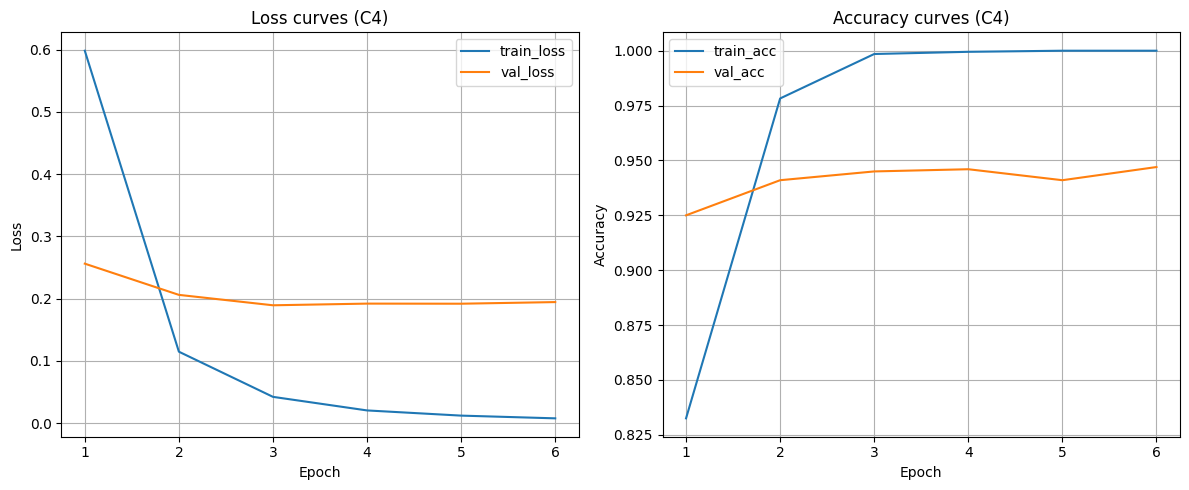

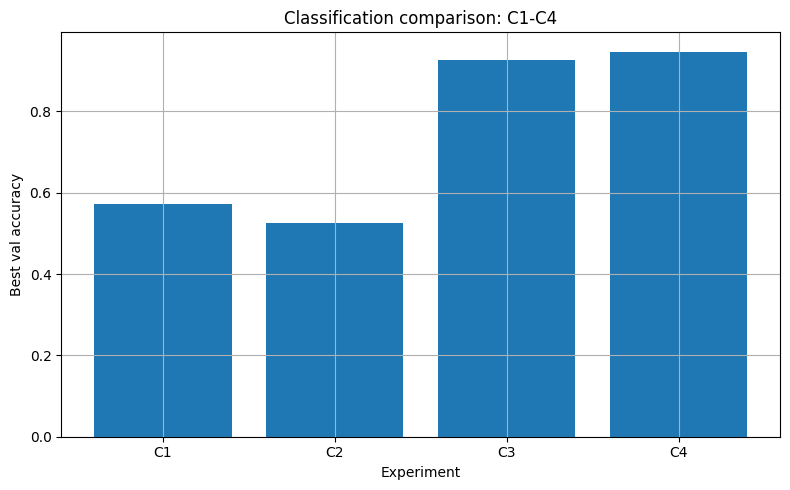

In [17]:
# ШАГ 28. Рисуем кривые лучшего эксперимента
best_history = best_result["history"]
epochs_range = range(1, len(best_history["train_loss"]) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, best_history["train_loss"], label="train_loss")
plt.plot(epochs_range, best_history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"Loss curves ({best_exp_id})")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, best_history["train_acc"], label="train_acc")
plt.plot(epochs_range, best_history["val_acc"], label="val_acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(f"Accuracy curves ({best_exp_id})")
plt.legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "classification_curves_best.png", dpi=150, bbox_inches="tight")
plt.show()


# ШАГ 29. Рисуем сравнение C1-C4 по best_val_accuracy
exp_ids = ["C1", "C2", "C3", "C4"]
val_accs = [classification_results[e]["best_val_accuracy"] for e in exp_ids]

plt.figure(figsize=(8, 5))
plt.bar(exp_ids, val_accs)
plt.xlabel("Experiment")
plt.ylabel("Best val accuracy")
plt.title("Classification comparison: C1-C4")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "classification_compare.png", dpi=150, bbox_inches="tight")
plt.show()

In [19]:
# ШАГ 30. Обновляем runs.csv:
# test_accuracy только для лучшей модели части A
df_runs = pd.read_csv(ARTIFACTS_DIR / "runs.csv")

for exp_id in ["C1", "C2", "C3", "C4"]:
    if exp_id == best_exp_id:
        df_runs.loc[df_runs["experiment_id"] == exp_id, "test_accuracy"] = float(best_result["test_accuracy"])
    else:
        df_runs.loc[df_runs["experiment_id"] == exp_id, "test_accuracy"] = np.nan

df_runs.to_csv(ARTIFACTS_DIR / "runs.csv", index=False)
df_runs

,experiment_id,task,dataset,seed,model_summary,optimizer,lr,epochs_trained,best_val_accuracy,test_accuracy,precision,recall,mean_iou,notes
0,C1,classification,STL10,42,SimpleCNN without augmentations,Adam,0.0010,8,0.573,NaN,NaN,NaN,NaN,simple-cnn-base
1,C2,classification,STL10,42,SimpleCNN with augmentations,Adam,0.0010,8,0.525,NaN,NaN,NaN,NaN,simple-cnn-aug
2,C3,classification,STL10,42,"ResNet18 pretrained, head-only training",Adam,0.0010,6,0.927,NaN,NaN,NaN,NaN,resnet18-head-only
3,C4,classification,STL10,42,"ResNet18 pretrained, partial fine-tuning (laye...",Adam,0.0001,6,0.947,0.94875,NaN,NaN,NaN,resnet18-finetune-layer4+fc


In [20]:
# ШАГ 31. Загружаем Pascal VOC Segmentation
voc_seg_raw = datasets.VOCSegmentation(
    root=DATA_DIR,
    year="2012",
    image_set="val",
    download=True,
    transform=None,
    target_transform=None,
)

print("VOC Segmentation size:", len(voc_seg_raw))

100.0%


VOC Segmentation size: 1449


In [23]:
# ШАГ 32. Определяем transforms для segmentation
seg_weights = DeepLabV3_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1

PERSON_CLASS_ID = 15
IGNORE_LABEL = 255

SEG_SIZE = 256 

seg_image_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    )
])

# ШАГ 33. Dataset для segmentation
class VOCSegmentationForInference(Dataset):
    def __init__(self, base_dataset, image_transform=None, size=256):
        self.base_dataset = base_dataset
        self.image_transform = image_transform
        self.size = size

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        image_pil, mask_pil = self.base_dataset[idx]

        image_pil_original = image_pil.copy()
        mask_pil_original = mask_pil.copy()

        image_resized = image_pil.resize((self.size, self.size), resample=Image.BILINEAR)
        mask_resized = mask_pil.resize((self.size, self.size), resample=Image.NEAREST)

        if self.image_transform is not None:
            image_tensor = self.image_transform(image_resized)
        else:
            image_tensor = transforms.ToTensor()(image_resized)

        mask_np = np.array(mask_resized, dtype=np.int64)
        mask_tensor = torch.tensor(mask_np, dtype=torch.long)

        return image_tensor, mask_tensor, image_pil_original, mask_pil_original


# ШАГ 34. Свой collate_fn для segmentation
def seg_collate_fn(batch):
    images = torch.stack([item[0] for item in batch], dim=0)
    masks = torch.stack([item[1] for item in batch], dim=0)
    image_pils = [item[2] for item in batch]
    mask_pils = [item[3] for item in batch]
    return images, masks, image_pils, mask_pils


voc_seg_ds = VOCSegmentationForInference(
    base_dataset=voc_seg_raw,
    image_transform=seg_image_transform,
    size=SEG_SIZE,
)

voc_seg_loader = DataLoader(
    voc_seg_ds,
    batch_size=4,
    shuffle=False,
    num_workers=0,
    collate_fn=seg_collate_fn,
)

seg_x, seg_mask, seg_pil, seg_mask_pil = next(iter(voc_seg_loader))
print("seg_x.shape:", seg_x.shape)
print("seg_mask.shape:", seg_mask.shape)
print("len(seg_pil):", len(seg_pil))
print("len(seg_mask_pil):", len(seg_mask_pil))
print("Batch loaded successfully.")

seg_x.shape: torch.Size([4, 3, 256, 256])
seg_mask.shape: torch.Size([4, 256, 256])
len(seg_pil): 4
len(seg_mask_pil): 4
Batch loaded successfully.


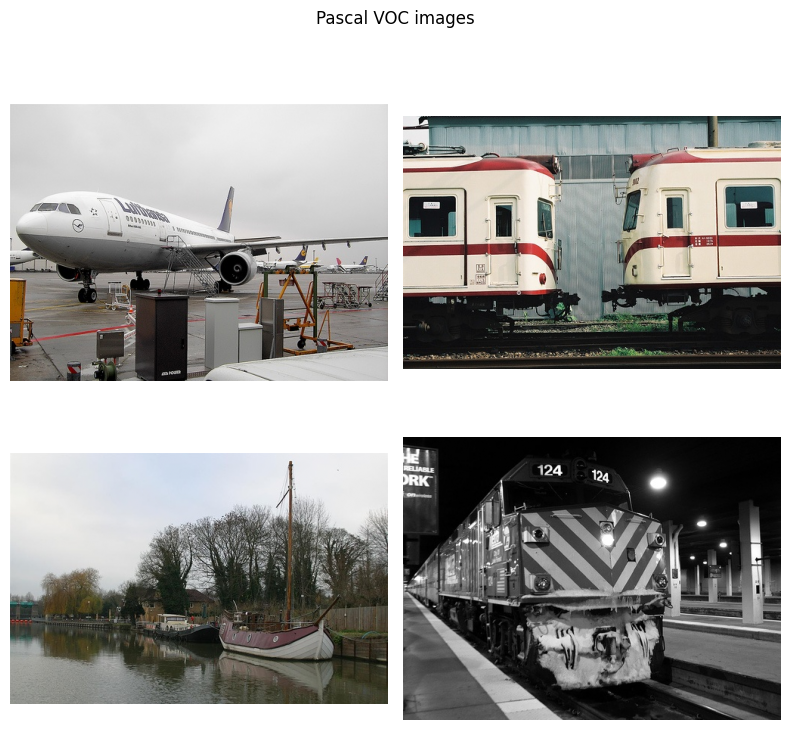

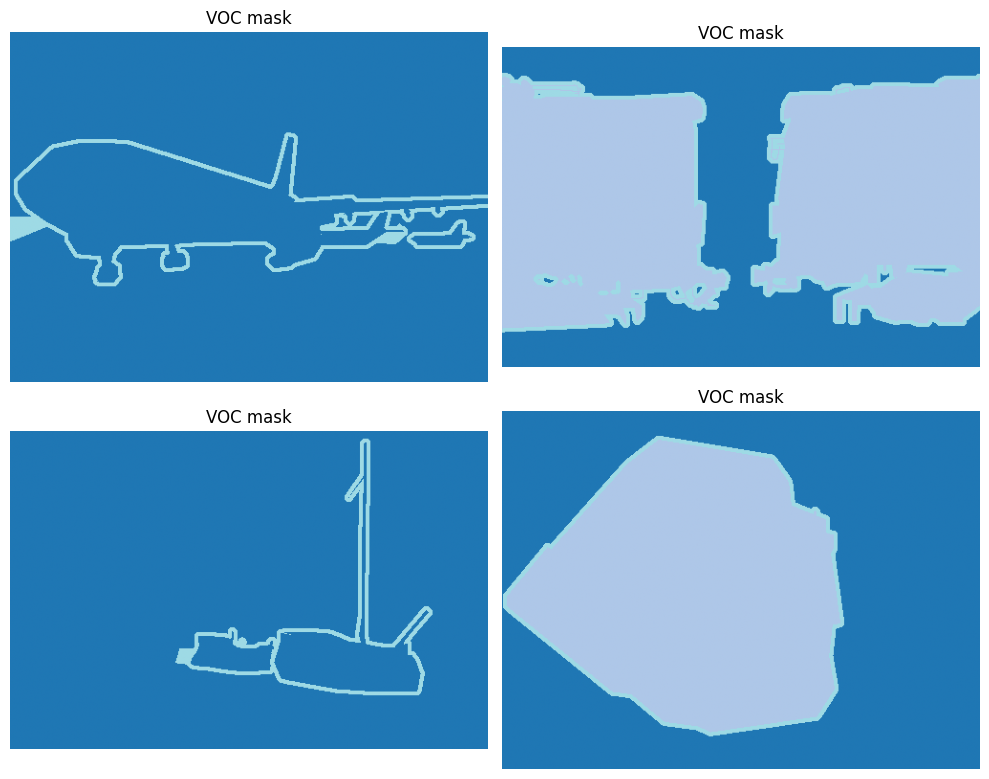

In [24]:
# ШАГ 34. Показываем примеры изображений и масок
samples_images = []
samples_masks = []

for i in range(4):
    image_pil, mask_pil = voc_seg_raw[i]
    samples_images.append(np.array(image_pil))
    samples_masks.append(np.array(mask_pil))

show_images(samples_images, ncols=2, title="Pascal VOC images")

plt.figure(figsize=(10, 8))
for i, mask in enumerate(samples_masks):
    plt.subplot(2, 2, i + 1)
    plt.imshow(mask, cmap="tab20")
    plt.axis("off")
    plt.title("VOC mask")
plt.tight_layout()
plt.show()

In [25]:
# ШАГ 35. Загружаем pretrained DeepLabV3
seg_model = models.segmentation.deeplabv3_resnet50(weights=seg_weights)
seg_model = seg_model.to(device)
seg_model.eval()

print("Segmentation model loaded.")

Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to C:\Users\Dilvi/.cache\torch\hub\checkpoints\deeplabv3_resnet50_coco-cd0a2569.pth


100.0%


Segmentation model loaded.


In [26]:
# ШАГ 36. Вспомогательные функции для segmentation
def mask_to_binary_foreground(mask_tensor, class_id=PERSON_CLASS_ID):
    """
    Переводим VOC mask в бинарную:
    1 = foreground (person)
    0 = всё остальное
    ignore=255 оставляем отдельно
    """
    gt = (mask_tensor == class_id).long()
    ignore = (mask_tensor == IGNORE_LABEL)
    return gt, ignore


def predict_person_mask(model, image_batch, threshold=0.5):
    """
    Получаем вероятности по классам и выделяем foreground-класс person
    через порог по softmax probability.
    """
    with torch.no_grad():
        outputs = model(image_batch.to(device))["out"]
        probs = torch.softmax(outputs, dim=1)
        person_prob = probs[:, PERSON_CLASS_ID, :, :]
        pred_bin = (person_prob >= threshold).long()
    return pred_bin.cpu(), person_prob.cpu()


def segmentation_metrics_binary(pred_bin, gt_bin, ignore_mask=None):
    """
    Считаем binary metrics:
    - IoU
    - pixel precision
    - pixel recall
    """
    if ignore_mask is None:
        valid = torch.ones_like(gt_bin, dtype=torch.bool)
    else:
        valid = ~ignore_mask

    pred = pred_bin[valid]
    gt = gt_bin[valid]

    tp = ((pred == 1) & (gt == 1)).sum().item()
    fp = ((pred == 1) & (gt == 0)).sum().item()
    fn = ((pred == 0) & (gt == 1)).sum().item()

    union = tp + fp + fn
    iou = tp / union if union > 0 else 0.0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0

    return {
        "iou": iou,
        "precision": precision,
        "recall": recall,
        "tp": tp,
        "fp": fp,
        "fn": fn,
    }

In [27]:
# ШАГ 37. Запускаем два режима оценки segmentation
def evaluate_segmentation_threshold(model, loader, threshold):
    ious = []
    precisions = []
    recalls = []

    visual_examples = []

    for image_tensor, mask_tensor, image_pil, mask_pil in loader:
        pred_bin, person_prob = predict_person_mask(model, image_tensor, threshold=threshold)

        for i in range(image_tensor.size(0)):
            gt_bin, ignore_mask = mask_to_binary_foreground(mask_tensor[i])

            metrics = segmentation_metrics_binary(
                pred_bin=pred_bin[i],
                gt_bin=gt_bin,
                ignore_mask=ignore_mask,
            )

            ious.append(metrics["iou"])
            precisions.append(metrics["precision"])
            recalls.append(metrics["recall"])

            if len(visual_examples) < 6:
                visual_examples.append({
                    "image_pil": image_pil[i],
                    "gt_bin": gt_bin.cpu(),
                    "pred_bin": pred_bin[i].cpu(),
                })

    return {
        "mean_iou": float(np.mean(ious)),
        "pixel_precision": float(np.mean(precisions)),
        "pixel_recall": float(np.mean(recalls)),
        "examples": visual_examples,
    }


result_v1 = evaluate_segmentation_threshold(seg_model, voc_seg_loader, threshold=0.5)
result_v2 = evaluate_segmentation_threshold(seg_model, voc_seg_loader, threshold=0.7)

print("V1:", result_v1["mean_iou"], result_v1["pixel_precision"], result_v1["pixel_recall"])
print("V2:", result_v2["mean_iou"], result_v2["pixel_precision"], result_v2["pixel_recall"])

V1: 0.21608354984419811 0.25403521906365883 0.2326175634909063
V2: 0.1994627712411334 0.25902590475389325 0.20641185494949063


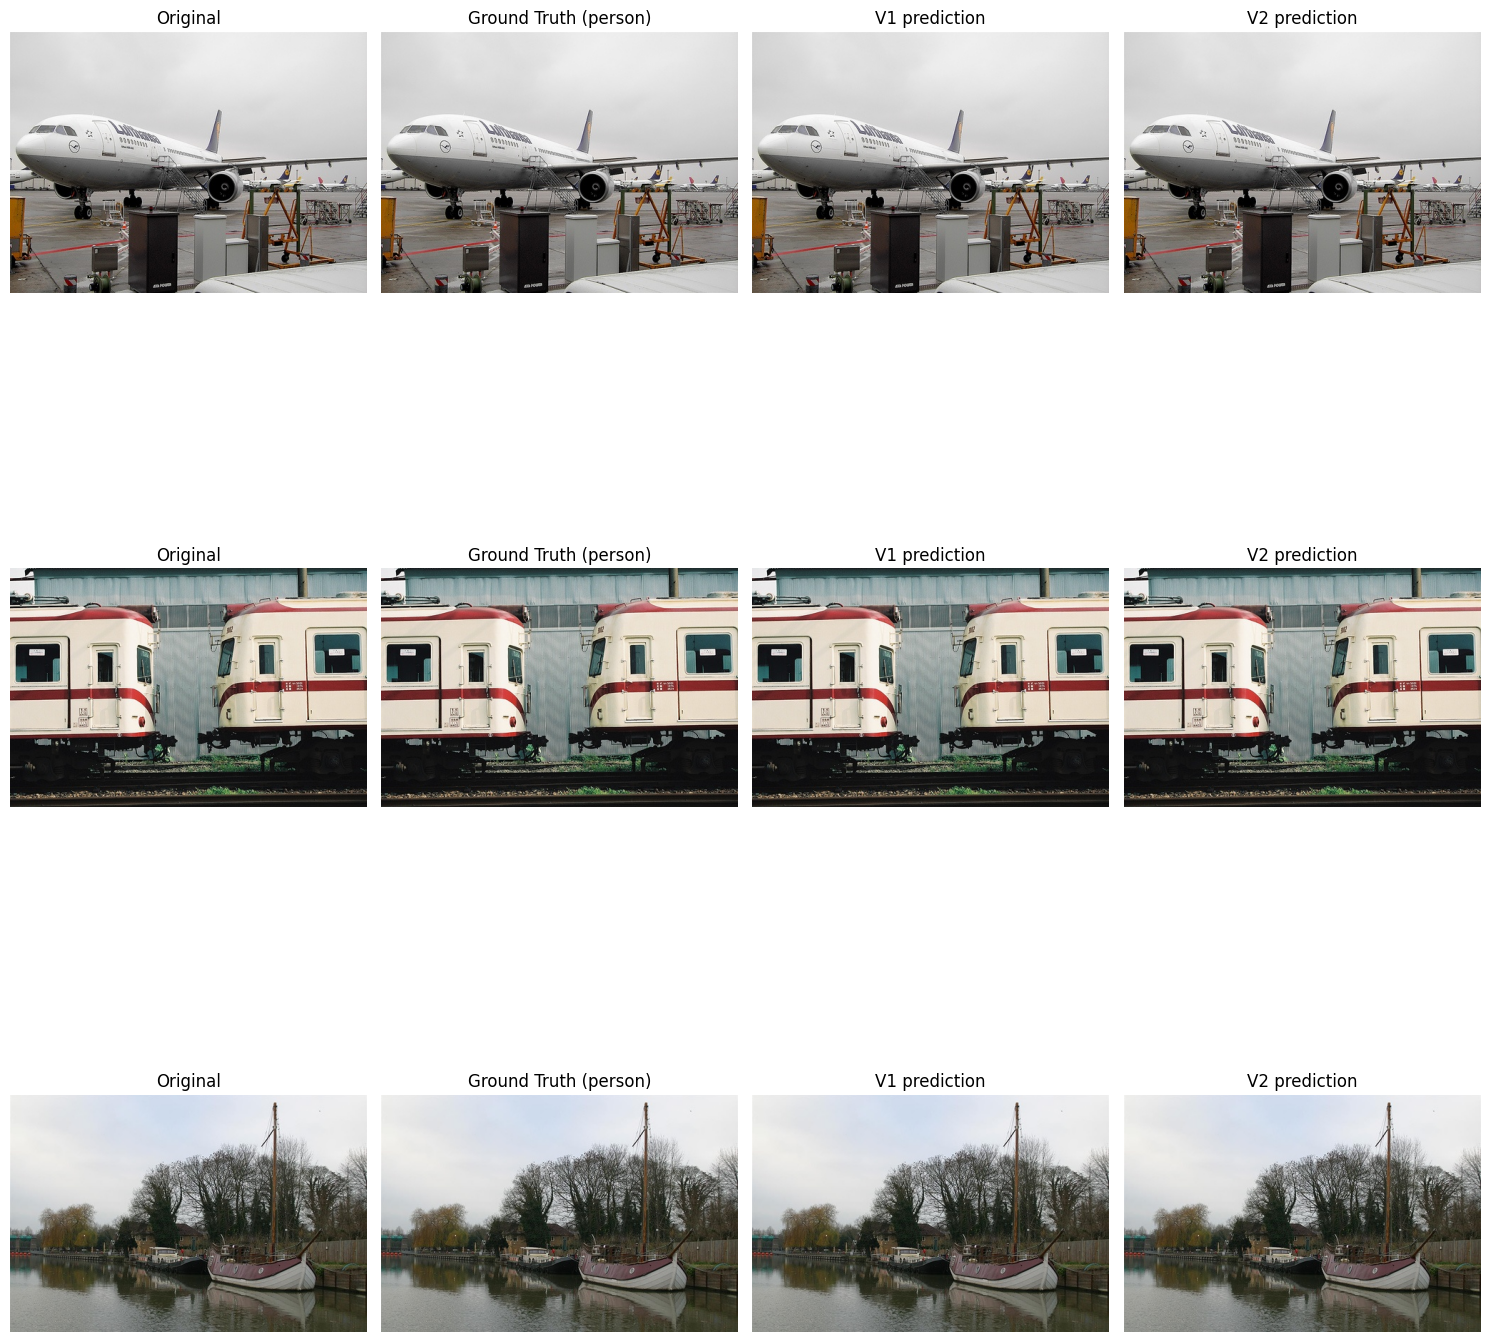

In [29]:
# ШАГ 38. Визуализируем prediction masks
def resize_binary_mask_to_image(binary_mask, image_pil):
    """
    binary_mask: torch.Tensor [H, W] со значениями 0/1 или bool
    image_pil: оригинальное PIL-изображение

    Возвращает bool-маску размера исходного изображения.
    """
    mask_np = binary_mask.cpu().numpy().astype(np.uint8) * 255
    mask_pil = Image.fromarray(mask_np)
    mask_resized = mask_pil.resize(image_pil.size, resample=Image.NEAREST)
    mask_resized_np = np.array(mask_resized) > 0
    return torch.tensor(mask_resized_np, dtype=torch.bool)


def overlay_mask_on_image(image_pil, binary_mask):
    """
    Накладывает бинарную маску на исходное изображение.
    """

    resized_mask = resize_binary_mask_to_image(binary_mask, image_pil)


    img_tensor = transforms.ToTensor()(image_pil)          
    img_uint8 = (img_tensor * 255).to(torch.uint8)         

    out = draw_segmentation_masks(
        image=img_uint8,
        masks=resized_mask.unsqueeze(0),
        alpha=0.5
    )

    out = out.permute(1, 2, 0).cpu().numpy()
    return out


def plot_segmentation_examples(examples_v1, examples_v2, save_path):
    plt.figure(figsize=(15, 18))

    n = min(3, len(examples_v1), len(examples_v2))

    for i in range(n):
        ex1 = examples_v1[i]
        ex2 = examples_v2[i]

        original_img = np.array(ex1["image_pil"])
        gt_overlay = overlay_mask_on_image(ex1["image_pil"], ex1["gt_bin"])
        pred_v1_overlay = overlay_mask_on_image(ex1["image_pil"], ex1["pred_bin"])
        pred_v2_overlay = overlay_mask_on_image(ex2["image_pil"], ex2["pred_bin"])

        plt.subplot(n, 4, i * 4 + 1)
        plt.imshow(original_img)
        plt.axis("off")
        plt.title("Original")

        plt.subplot(n, 4, i * 4 + 2)
        plt.imshow(gt_overlay)
        plt.axis("off")
        plt.title("Ground Truth (person)")

        plt.subplot(n, 4, i * 4 + 3)
        plt.imshow(pred_v1_overlay)
        plt.axis("off")
        plt.title("V1 prediction")

        plt.subplot(n, 4, i * 4 + 4)
        plt.imshow(pred_v2_overlay)
        plt.axis("off")
        plt.title("V2 prediction")

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


plot_segmentation_examples(
    result_v1["examples"],
    result_v2["examples"],
    FIGURES_DIR / "segmentation_examples.png"
)

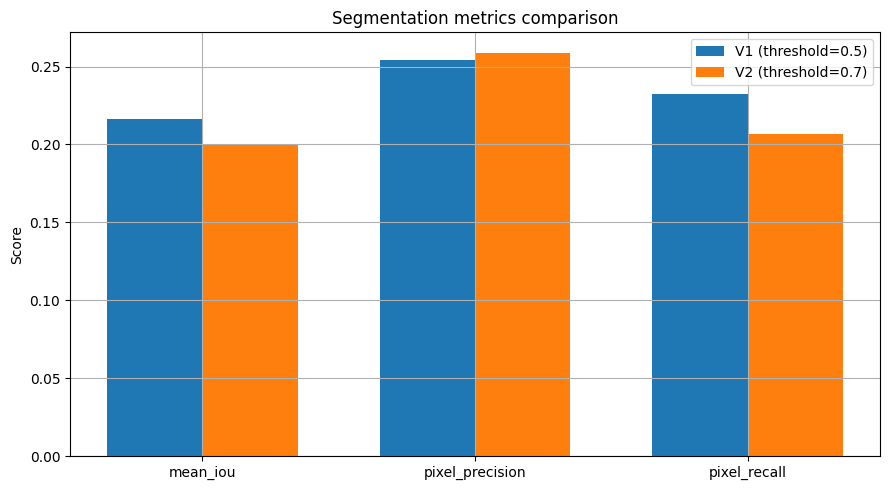

In [31]:
# ШАГ 39. Рисуем и сохраняем segmentation_metrics.png
metrics_names = ["mean_iou", "pixel_precision", "pixel_recall"]
v1_values = [result_v1["mean_iou"], result_v1["pixel_precision"], result_v1["pixel_recall"]]
v2_values = [result_v2["mean_iou"], result_v2["pixel_precision"], result_v2["pixel_recall"]]

x = np.arange(len(metrics_names))
width = 0.35

plt.figure(figsize=(9, 5))
plt.bar(x - width / 2, v1_values, width, label="V1 (threshold=0.5)")
plt.bar(x + width / 2, v2_values, width, label="V2 (threshold=0.7)")
plt.xticks(x, metrics_names)
plt.ylabel("Score")
plt.title("Segmentation metrics comparison")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "segmentation_metrics.png", dpi=150, bbox_inches="tight")
plt.show()

In [32]:
# ШАГ 40. Добавляем V1 и V2 в runs.csv
append_run({
    "experiment_id": "V1",
    "task": "segmentation",
    "dataset": "Pascal VOC 2012",
    "seed": SEED,
    "model_summary": "DeepLabV3_ResNet50 pretrained, foreground=person, threshold=0.5",
    "optimizer": "",
    "lr": "",
    "epochs_trained": 0,
    "best_val_accuracy": "",
    "test_accuracy": "",
    "precision": result_v1["pixel_precision"],
    "recall": result_v1["pixel_recall"],
    "mean_iou": result_v1["mean_iou"],
    "notes": "Segmentation track, V1 basic postprocessing",
})

append_run({
    "experiment_id": "V2",
    "task": "segmentation",
    "dataset": "Pascal VOC 2012",
    "seed": SEED,
    "model_summary": "DeepLabV3_ResNet50 pretrained, foreground=person, threshold=0.7",
    "optimizer": "",
    "lr": "",
    "epochs_trained": 0,
    "best_val_accuracy": "",
    "test_accuracy": "",
    "precision": result_v2["pixel_precision"],
    "recall": result_v2["pixel_recall"],
    "mean_iou": result_v2["mean_iou"],
    "notes": "Segmentation track, V2 alternative threshold postprocessing",
})

pd.read_csv(ARTIFACTS_DIR / "runs.csv")

,experiment_id,task,dataset,seed,model_summary,optimizer,lr,epochs_trained,best_val_accuracy,test_accuracy,precision,recall,mean_iou,notes
0,C1,classification,STL10,42,SimpleCNN without augmentations,Adam,0.0010,8,0.573,NaN,NaN,NaN,NaN,simple-cnn-base
1,C2,classification,STL10,42,SimpleCNN with augmentations,Adam,0.0010,8,0.525,NaN,NaN,NaN,NaN,simple-cnn-aug
2,C3,classification,STL10,42,"ResNet18 pretrained, head-only training",Adam,0.0010,6,0.927,NaN,NaN,NaN,NaN,resnet18-head-only
3,C4,classification,STL10,42,"ResNet18 pretrained, partial fine-tuning (laye...",Adam,0.0001,6,0.947,0.94875,NaN,NaN,NaN,resnet18-finetune-layer4+fc
4,V1,segmentation,Pascal VOC 2012,42,"DeepLabV3_ResNet50 pretrained, foreground=pers...",NaN,NaN,0,NaN,NaN,0.254035,0.232618,0.216084,"Segmentation track, V1 basic postprocessing"
5,V2,segmentation,Pascal VOC 2012,42,"DeepLabV3_ResNet50 pretrained, foreground=pers...",NaN,NaN,0,NaN,NaN,0.259026,0.206412,0.199463,"Segmentation track, V2 alternative threshold p..."


In [33]:
# ШАГ 41. Проверяем, что все нужные артефакты созданы
required_files = [
    ARTIFACTS_DIR / "runs.csv",
    ARTIFACTS_DIR / "best_classifier.pt",
    ARTIFACTS_DIR / "best_classifier_config.json",
    FIGURES_DIR / "classification_curves_best.png",
    FIGURES_DIR / "classification_compare.png",
    FIGURES_DIR / "augmentations_preview.png",
    FIGURES_DIR / "segmentation_examples.png",
    FIGURES_DIR / "segmentation_metrics.png",
]

for file_path in required_files:
    print(file_path, "->", file_path.exists())

artifacts\runs.csv -> True
artifacts\best_classifier.pt -> True
artifacts\best_classifier_config.json -> True
artifacts\figures\classification_curves_best.png -> True
artifacts\figures\classification_compare.png -> True
artifacts\figures\augmentations_preview.png -> True
artifacts\figures\segmentation_examples.png -> True
artifacts\figures\segmentation_metrics.png -> True
